# Proceso de forecasting y extracción de variables autorregresivas

Este cuaderno tiene como objetivo realizar el proceso de forecasting sobre los datos de sensores de los aeropuertos. 

In [ ]:
import pandas as pd

aeropuerto = 'LEST'

data = pd.read_csv(f'datasets/{aeropuerto}_sensors.csv')
data.head(30)

,year,month,day,hour,minute,wind_dir,wind_speed,temp,dewpt,press,vis
0,2010,1,1,0,0,180.0,4.0,11.0,10.0,1002.0,8000.0
1,2010,1,1,1,0,200.0,12.0,11.0,10.0,1002.0,4000.0
2,2010,1,1,2,0,215.0,13.5,11.0,10.0,1001.0,6000.0
3,2010,1,1,3,0,230.0,15.0,11.0,10.0,1000.0,8000.0
4,2010,1,1,4,0,230.0,13.0,11.0,10.0,1000.0,8000.0
5,2010,1,1,5,0,220.0,11.0,11.0,10.0,1000.0,6000.0
6,2010,1,1,6,0,270.0,8.0,11.0,10.0,1000.0,9000.0
7,2010,1,1,7,0,300.0,8.0,11.0,10.0,1002.0,10000.0
8,2010,1,1,8,0,310.0,8.0,11.0,10.0,1004.0,10000.0
9,2010,1,1,9,0,310.0,13.0,11.0,10.0,1005.0,10000.0


### Clasificación de la visibilidad
A continuación, definimos diferentes intervalos (bins) para clasificar la variable `vis` (visibilidad) en diferentes categorías discretas: Muy baja, Baja, Media y Alta.

In [ ]:
import numpy as np

bins = [-np.inf, 500, 1000, 5000, np.inf]
labels = ["Muy baja", "Baja", "Media", "Alta"]

data['vis_class'] = pd.cut(data['vis'], bins=bins, labels=labels, right=False)

print(data[['vis', 'vis_class']].head(30))

        vis vis_class
0    8000.0      Alta
1    4000.0     Media
2    6000.0      Alta
3    8000.0      Alta
4    8000.0      Alta
5    6000.0      Alta
6    9000.0      Alta
7   10000.0      Alta
8   10000.0      Alta
9   10000.0      Alta
10  10000.0      Alta
11  10000.0      Alta
12  10000.0      Alta
13  10000.0      Alta
14  10000.0      Alta
15  10000.0      Alta
16  10000.0      Alta
17  10000.0      Alta
18  10000.0      Alta
19  10000.0      Alta
20   8000.0      Alta
21  10000.0      Alta
22  10000.0      Alta
23  10000.0      Alta
24   8000.0      Alta
25  10000.0      Alta
26  10000.0      Alta
27  10000.0      Alta
28  10000.0      Alta
29  10000.0      Alta


### Distribución de clases

In [ ]:
print("Distribución de las clases: ")
data['vis_class'].value_counts(normalize=True).round(3)

Distribución de las clases: 


vis_class
Alta        0.856
Media       0.076
Muy baja    0.045
Baja        0.023
Name: proportion, dtype: float64

### Tratamiento de fechas e indexación
Convertimos las columnas separadas de tiempo (`year`, `month`, `day`, `hour`, `minute`) en un formato de fecha `datetime`. Posteriormente, establecemos esta nueva columna temporal como índice del *dataset*, forzamos una frecuencia horaria y ordenamos cronológicamente para tener una serie temporal bien estructurada.

In [ ]:
data['date'] = pd.to_datetime(data[['year', 'month', 'day', 'hour', 'minute']])
data = data.set_index('date').asfreq('H')
data = data.sort_index()

print(data.tail())

                     year  month  day  hour  minute  wind_dir  wind_speed  \
date                                                                        
2023-12-31 19:00:00  2023     12   31    19       0     245.0         2.0   
2023-12-31 20:00:00  2023     12   31    20       0     210.0         4.0   
2023-12-31 21:00:00  2023     12   31    21       0     220.0         4.0   
2023-12-31 22:00:00  2023     12   31    22       0     190.0         6.0   
2023-12-31 23:00:00  2023     12   31    23       0     190.0         7.0   

                     temp  dewpt   press      vis vis_class  
date                                                         
2023-12-31 19:00:00   8.0    5.0  1020.0  10000.0      Alta  
2023-12-31 20:00:00   8.0    5.0  1020.0  10000.0      Alta  
2023-12-31 21:00:00   8.0    6.0  1021.0  10000.0      Alta  
2023-12-31 22:00:00   8.0    6.0  1021.0  10000.0      Alta  
2023-12-31 23:00:00   8.0    7.0  1020.0  10000.0      Alta  


C:\Users\jorge\AppData\Local\Temp\ipykernel_26288\4122337642.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data = data.set_index('date').asfreq('H')


### Transformación de la dirección del viento
Dado que la dirección del viento (`wind_dir`) es una variable circular, si la usamos tal cual en un modelo numérico, este interpretará erróneamente que 359° y 1° son valores muy distantes. 

Para solucionar esto, transformamos los grados a radianes y extraemos sus componentes **seno** y **coseno**, obteniendo dos nuevas variables continuas (`wind_sin` y `wind_cos`) que representan correctamente esta naturaleza circular.

In [ ]:
import numpy as np

# Función auxiliar para transformar el viento en tus datos originales
def transformar_viento(df):
    # Convertir grados a radianes
    wd_rad = df['wind_dir'] * np.pi / 180
    df['wind_sin'] = np.sin(wd_rad)
    df['wind_cos'] = np.cos(wd_rad)
    return df

data = transformar_viento(data)

data.head(10)

,year,month,day,hour,minute,wind_dir,wind_speed,temp,dewpt,press,vis,vis_class,wind_sin,wind_cos
date,,,,,,,,,,,,,,
2010-01-01 00:00:00,2010,1,1,0,0,180.0,4.0,11.0,10.0,1002.0,8000.0,Alta,1.224647e-16,-1.000000e+00
2010-01-01 01:00:00,2010,1,1,1,0,200.0,12.0,11.0,10.0,1002.0,4000.0,Media,-3.420201e-01,-9.396926e-01
2010-01-01 02:00:00,2010,1,1,2,0,215.0,13.5,11.0,10.0,1001.0,6000.0,Alta,-5.735764e-01,-8.191520e-01
2010-01-01 03:00:00,2010,1,1,3,0,230.0,15.0,11.0,10.0,1000.0,8000.0,Alta,-7.660444e-01,-6.427876e-01
2010-01-01 04:00:00,2010,1,1,4,0,230.0,13.0,11.0,10.0,1000.0,8000.0,Alta,-7.660444e-01,-6.427876e-01
2010-01-01 05:00:00,2010,1,1,5,0,220.0,11.0,11.0,10.0,1000.0,6000.0,Alta,-6.427876e-01,-7.660444e-01
2010-01-01 06:00:00,2010,1,1,6,0,270.0,8.0,11.0,10.0,1000.0,9000.0,Alta,-1.000000e+00,-1.836970e-16
2010-01-01 07:00:00,2010,1,1,7,0,300.0,8.0,11.0,10.0,1002.0,10000.0,Alta,-8.660254e-01,5.000000e-01
2010-01-01 08:00:00,2010,1,1,8,0,310.0,8.0,11.0,10.0,1004.0,10000.0,Alta,-7.660444e-01,6.427876e-01


### División en Entrenamiento (Train) y Prueba (Test)
Dado que estamos trabajando con series temporales, no podemos dividir los datos aleatoriamente. Respetaremos el orden cronológico y utilizaremos el 75% más antiguo del *dataset* para entrenar (Train) y el 25% más reciente para probar y validar nuestros modelos (Test).


In [ ]:
split_index = int(len(data) * 0.75)

data_train = data.iloc[:split_index].copy()
data_test  = data.iloc[split_index:].copy()

print(
    f"Train dates : {data_train.index.min()} --- "
    f"{data_train.index.max()}  (n={len(data_train)})"
)
print(
    f"Test dates  : {data_test.index.min()} --- "
    f"{data_test.index.max()}  (n={len(data_test)})"
)

Train dates : 2010-01-01 00:00:00 --- 2020-07-01 17:00:00  (n=92034)
Test dates  : 2020-07-01 18:00:00 --- 2023-12-31 23:00:00  (n=30678)


### Codificación de la variable objetivo (Target)
Para poder entrenar nuestros modelos predictivos o generar variables autorregresivas, necesitamos que nuestra clase objetivo (visibilidad) sea numérica. Por lo tanto, mapeamos las categorías categóricas ordinales a valores enteros (de 0 a 3). Esto lo hacemos tanto para el conjunto completo como para las particiones de entrenamiento y test.

In [ ]:
# Codificar la variable categórica 'vis_class' como numérica
encode_mapping = {
    "Muy baja": 0,
    "Baja": 1,
    "Media": 2,
    "Alta": 3
}
print(f"Encoding map: {encode_mapping}")

data['encoded_value'] = data['vis_class'].map(encode_mapping).astype(float)
data_train['encoded_value'] = data_train['vis_class'].map(encode_mapping).astype(float)
data_test['encoded_value'] = data_test['vis_class'].map(encode_mapping).astype(float)

data.head(3)

Encoding map: {'Muy baja': 0, 'Baja': 1, 'Media': 2, 'Alta': 3}


,year,month,day,hour,minute,wind_dir,wind_speed,temp,dewpt,press,vis,vis_class,wind_sin,wind_cos,encoded_value
date,,,,,,,,,,,,,,,
2010-01-01 00:00:00,2010,1,1,0,0,180.0,4.0,11.0,10.0,1002.0,8000.0,Alta,1.224647e-16,-1.000000,3.0
2010-01-01 01:00:00,2010,1,1,1,0,200.0,12.0,11.0,10.0,1002.0,4000.0,Media,-3.420201e-01,-0.939693,2.0
2010-01-01 02:00:00,2010,1,1,2,0,215.0,13.5,11.0,10.0,1001.0,6000.0,Alta,-5.735764e-01,-0.819152,3.0


### Definición del Modelo y del Pronosticador (Forecaster)
Vamos a definir la estructura de nuestro modelo predictivo. Utilizaremos un modelo **LightGBM** optimizado para clasificación (`LGBMClassifier`). Como trabajamos con series temporales, en lugar de predecir de forma aislada, utilizaremos un **Forecaster Recursivo** de la librería `skforecast`. 

Este pronosticador generará automáticamente los rezagos (*lags*) de las 24 horas anteriores, además de calcular características dinámicas de ventana móvil (*Rolling Features*), en este caso, la proporción de cada clase en las últimas 72 horas.

In [ ]:
from skforecast.preprocessing import RollingFeaturesClassification
from lightgbm import LGBMClassifier
from skforecast.recursive import ForecasterRecursiveClassifier

window_features = RollingFeaturesClassification(stats=['proportion'], window_sizes=72)

regressor = LGBMClassifier(random_state=123, verbose=-1, class_weight='balanced')

forecaster = ForecasterRecursiveClassifier(
    estimator = regressor,
    lags=24,
    window_features=window_features,
    features_encoding='ordinal',
)

forecaster

============================= 
ForecasterRecursiveClassifier 
============================= 
Estimator: LGBMClassifier 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: ['roll_proportion_72'] 
Window size: 72 
Series name: None 
Classes: None 
Number of classes: None 
Exogenous included: False 
Exogenous names: None 
Feature encoding: ordinal 
Transformer for exog: None 
Weight function included: False 
Training range: None 
Training index type: None 
Training index frequency: None 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': 'balanced', 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-08 19:53:42 
Last fit date: None 
Skforecast version: 0.19.1 
Python version: 3.13.11 
Forecaster id: None

### Entrenamiento del Modelo
Una vez definida la estructura del `forecaster`, procedemos a entrenarlo. Para ello, le pasamos nuestra variable objetivo o clase a predecir (`y`) junto con el resto de variables meteorológicas que actúan como variables exógenas o predictoras auxiliares (`exog`).


In [ ]:
exog_variables = ['wind_sin', 'wind_cos', 'wind_speed', 'temp', 'dewpt', 'press']

exog_train = data_train[exog_variables]
exog_test = data_test[exog_variables]

forecaster.fit(
    y = data_train['encoded_value'],
    exog = exog_train
)

forecaster

============================= 
ForecasterRecursiveClassifier 
============================= 
Estimator: LGBMClassifier 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: ['roll_proportion_72'] 
Window size: 72 
Series name: encoded_value 
Classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)] 
Number of classes: 4 
Exogenous included: True 
Exogenous names: wind_sin, wind_cos, wind_speed, temp, dewpt, press 
Feature encoding: ordinal 
Transformer for exog: None 
Weight function included: False 
Training range: [Timestamp('2010-01-01 00:00:00'), Timestamp('2020-07-01 17:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': 'balanced', 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-08 19:53:42 
Last fit date: 2026-06-08 19:54:52 
Skforecast version: 0.19.1 
Python version: 3.13.11 
Forecaster id: None

### Importancia de las variables (Feature Importance)
Para entender mejor en qué se basa nuestro modelo para realizar las predicciones, extraemos la importancia de las variables (tanto de las exógenas como de los rezagos -*lags*- creados internamente). Esto nos ayuda a interpretar el peso que tiene cada parámetro meteorológico y de histórico en la predicción final.


In [ ]:
print(forecaster.get_feature_importances())

                         feature  importance
31                          temp        1300
32                         dewpt        1180
33                         press        1038
30                    wind_speed         890
28                      wind_sin         876
29                      wind_cos         769
26  roll_proportion_72_class_2.0         730
27  roll_proportion_72_class_3.0         701
24  roll_proportion_72_class_0.0         556
0                          lag_1         514
25  roll_proportion_72_class_1.0         484
1                          lag_2         313
2                          lag_3         226
3                          lag_4         210
4                          lag_5         201
5                          lag_6         154
7                          lag_8         146
6                          lag_7         124
18                        lag_19         123
10                        lag_11         120
23                        lag_24         117
22        

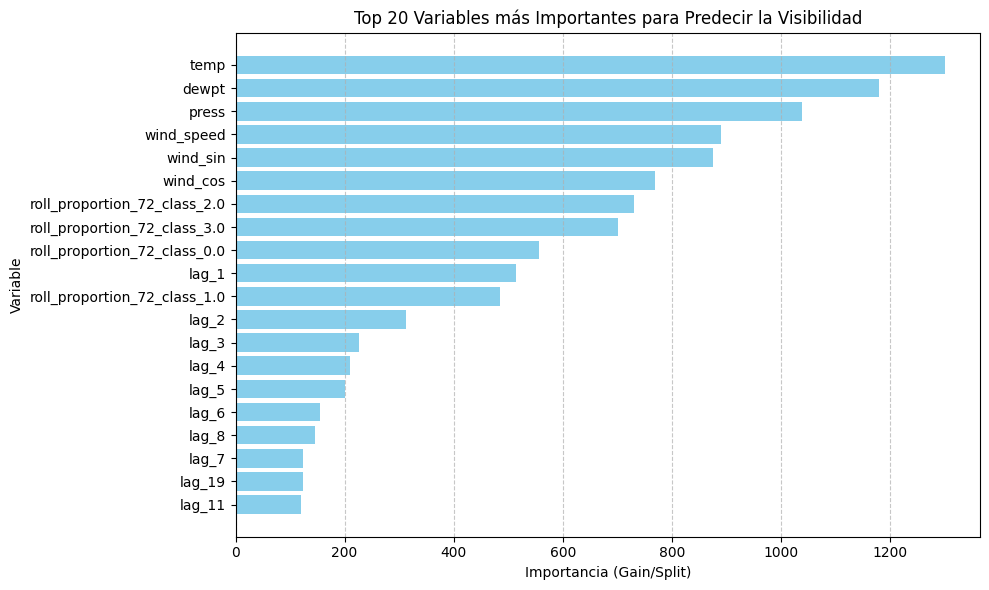

In [ ]:
import matplotlib.pyplot as plt

importancia = forecaster.get_feature_importances()

importancia_plot = importancia.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importancia_plot['feature'], importancia_plot['importance'], color='skyblue')
plt.xlabel("Importancia (Gain/Split)")
plt.ylabel("Variable")
plt.title("Top 20 Variables más Importantes para Predecir la Visibilidad")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Generar el conjunto de datos completo con las variables autorregresivas
X_completo, y_completo = forecaster.create_train_X_y(
    y = data['encoded_value'],
    exog = data[exog_variables]
)

# 2. Volver a dividir en Train y Test
# Ya que hemos perdido las primeras 72 filas, porque skforecast las utiliza para generar las variables
fecha_corte = data_test.index[0] # Cogemos la primera fecha de data_test original

# Dividimos usando el índice de fechas
X_train_final = X_completo.loc[:fecha_corte].iloc[:-1] 
y_train_final = y_completo.loc[:fecha_corte].iloc[:-1]

X_test_final = X_completo.loc[fecha_corte:]
y_test_final = y_completo.loc[fecha_corte:]

print(f"Tamaño de X_train: {X_train_final.shape}")
print(f"Tamaño de X_test:  {X_test_final.shape}")
print("\nColumnas listas para usar en tus algoritmos manuales:")
print(X_train_final.columns.tolist())

X_train_final.head()


Tamaño de X_train: (91962, 34)
Tamaño de X_test:  (30678, 34)

Columnas listas para usar en tus algoritmos manuales:
['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'roll_proportion_72_class_0.0', 'roll_proportion_72_class_1.0', 'roll_proportion_72_class_2.0', 'roll_proportion_72_class_3.0', 'wind_sin', 'wind_cos', 'wind_speed', 'temp', 'dewpt', 'press']


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,roll_proportion_72_class_0.0,roll_proportion_72_class_1.0,roll_proportion_72_class_2.0,roll_proportion_72_class_3.0,wind_sin,wind_cos,wind_speed,temp,dewpt,press
date,,,,,,,,,,,,,,,,,,,,,
2010-01-04 00:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.180556,0.791667,0.970296,0.241922,3.0,9.0,8.0,1010.0
2010-01-04 01:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.180556,0.791667,0.642788,0.766044,4.0,7.0,6.0,1009.0
2010-01-04 02:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.166667,0.805556,0.766044,0.642788,6.0,7.0,6.0,1009.0
2010-01-04 03:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.166667,0.805556,0.642788,0.766044,4.0,7.0,6.0,1009.0
2010-01-04 04:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.166667,0.805556,0.642788,0.766044,4.0,7.0,6.0,1009.0


### Entrenamiento de un Modelo Ordinal (LogisticIT)
Como la visibilidad es una variable ordinal (tiene un orden lógico: Muy baja < Baja < Media < Alta), un modelo puramente categórico como LGBM puede perder esa relación de orden. 

Para mejorarlo, utilizaremos **LogisticIT** de la librería `mord` (Modelos Ordinales). Además, dado que las clases minoritarias (baja visibilidad o niebla) son muy escasas, hemos creado un *wrapper* o clase envolvente personalizada que balancea automáticamente los pesos de las clases, forzando al modelo a prestar más atención a esos eventos críticos.


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from mord import LogisticIT
from skforecast.preprocessing import RollingFeaturesClassification
from skforecast.recursive import ForecasterRecursiveClassifier

class LogisticIT_Balanced_Auto(LogisticIT):
    def fit(self, X, y):
        y = y.astype(int)

        weights = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=weights)

    def predict(self, X):
        return super().predict(X)

    def predict_proba(self, X):
        return super().predict_proba(X)

# ---------------------------------------------------------

modelo_ordinal_auto = LogisticIT_Balanced_Auto(alpha=1.0, verbose=0)

window_features = RollingFeaturesClassification(stats=['proportion'], window_sizes=72)

forecaster_ordinal = ForecasterRecursiveClassifier(
    estimator         = modelo_ordinal_auto,
    lags              = 24,
    window_features   = window_features,
    features_encoding = 'ordinal'
)

forecaster_ordinal.fit(
    y    = data_train['encoded_value'],
    exog = exog_train
)

print("✅ Modelo Ordinal Balanceado entrenado correctamente.")


✅ Modelo Ordinal Balanceado entrenado correctamente.


### Backtesting del Modelo Ordinal
Para evaluar de forma robusta cómo se comportaría nuestro modelo en la vida real, utilizamos una técnica de validación cruzada para series temporales llamada **Backtesting**. En lugar de hacer una única predicción, el modelo predice paso a paso (en bloques de 24 horas) a lo largo de todo el conjunto de prueba (`Test`), simulando el flujo natural del tiempo y proporcionándonos la precisión global (*Accuracy*).

In [ ]:
from skforecast.model_selection import backtesting_forecaster
from skforecast.model_selection import TimeSeriesFold
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cv = TimeSeriesFold(
    steps              = 24,
    initial_train_size = split_index,
    refit              = False
)

print("Iniciando backtesting con LogisticIT (esto puede tardar un poco más)...")
metric_ordinal, preds_ordinal = backtesting_forecaster(
    forecaster    = forecaster_ordinal,
    y             = data['encoded_value'],
    exog          = data[exog_variables],
    cv            = cv,
    metric        = 'accuracy_score',
    n_jobs        = 'auto',
    verbose       = False,
    show_progress = True
)

print(f"Accuracy Global Ordinal: {metric_ordinal}")


Iniciando backtesting con LogisticIT (esto puede tardar un poco más)...


  0%|          | 0/1279 [00:00<?, ?it/s]

Accuracy Global Ordinal:    accuracy_score
0        0.792457


### Extracción de Variables Autorregresivas y Matrices Finales
Para poder utilizar modelos externos que no pertenecen a `skforecast`, o para guardar nuestro *dataset* final con todas las variables que ha calculado internamente el pronosticador (los rezagos de las últimas 24 horas y las ventanas móviles de 72 horas), usamos la función `create_train_X_y()`. 

Dado que al calcular características de hasta 72 horas hacia atrás las primeras 72 filas del conjunto se pierden (se rellenan con `NaN` y se eliminan), reajustamos cuidadosamente nuestra separación de Entrenamiento y Prueba utilizando la fecha exacta en lugar del índice numérico.


In [ ]:
X_completo, y_completo = forecaster_ordinal.create_train_X_y(
    y    = data['encoded_value'],
    exog = data[exog_variables]
)

# Volvemos a dividir en Train/Test
# Como hemos perdido las primeras 72 filas porque skforecast las necesita para calcular los primeros rolling, el 'split_index' antiguo ya no nos vale.

fecha_corte = data_test.index[0] # Cogemos la primera fecha de tu data_test original

# Dividimos usando el índice de fechas
X_train_final = X_completo.loc[:fecha_corte].iloc[:-1]
y_train_final = y_completo.loc[:fecha_corte].iloc[:-1]

X_test_final = X_completo.loc[fecha_corte:]
y_test_final = y_completo.loc[fecha_corte:]

print(f"Tamaño de X_train: {X_train_final.shape}")
print(f"Tamaño de X_test:  {X_test_final.shape}")
print("\nColumnas listas para usar en tus algoritmos manuales:")
print(X_train_final.columns.tolist())

X_train_final.head()


Tamaño de X_train: (91962, 34)
Tamaño de X_test:  (30678, 34)

Columnas listas para usar en tus algoritmos manuales:
['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'roll_proportion_72_class_0.0', 'roll_proportion_72_class_1.0', 'roll_proportion_72_class_2.0', 'roll_proportion_72_class_3.0', 'wind_sin', 'wind_cos', 'wind_speed', 'temp', 'dewpt', 'press']


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,roll_proportion_72_class_0.0,roll_proportion_72_class_1.0,roll_proportion_72_class_2.0,roll_proportion_72_class_3.0,wind_sin,wind_cos,wind_speed,temp,dewpt,press
date,,,,,,,,,,,,,,,,,,,,,
2010-01-04 00:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.180556,0.791667,0.970296,0.241922,3.0,9.0,8.0,1010.0
2010-01-04 01:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.180556,0.791667,0.642788,0.766044,4.0,7.0,6.0,1009.0
2010-01-04 02:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.166667,0.805556,0.766044,0.642788,6.0,7.0,6.0,1009.0
2010-01-04 03:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.166667,0.805556,0.642788,0.766044,4.0,7.0,6.0,1009.0
2010-01-04 04:00:00,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.027778,0.166667,0.805556,0.642788,0.766044,4.0,7.0,6.0,1009.0


### Selección de las variables más importantes
Una vez extraídas todas las variables generadas automáticamente por el `forecaster`, podemos filtrarlas para quedarnos solo con aquellas que nuestro análisis previo determinó como más importantes. Esto nos permite simplificar nuestros modelos reduciendo el ruido de variables poco predictivas.

Hemos seleccionado:
1. Variables meteorológicas básicas transformadas.
2. La proporción de las clases en las últimas 72 horas (tendencia a medio plazo).
3. Los rezagos de las últimas 6 horas (inercia a muy corto plazo).
4. El rezago exacto de hace 24 horas (estacionalidad diaria).


In [ ]:
columnas_top = [
    # 1. Variables Meteorológicas
    'temp', 'dewpt', 'press', 'wind_sin', 'wind_cos', 'wind_speed',

    # 2. Tendencia a Medio Plazo
    'roll_proportion_72_class_3.0',
    'roll_proportion_72_class_2.0',
    'roll_proportion_72_class_1.0',
    'roll_proportion_72_class_0.0',

    # 3. Memoria Inmediata
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_5',
    'lag_6',

    # 4. Estacionalidad Diaria
    'lag_24'
]

X_train_top = X_train_final[columnas_top]
X_test_top  = X_test_final[columnas_top]


### Guardar el conjunto de datos final
Para terminar, volvemos a unir todas las particiones (Train y Test) en un único *dataset* ordenado cronológicamente. Añadimos también la variable objetivo original (`vis`, en metros) por si la necesitamos en el futuro, y exportamos el resultado a un nuevo archivo CSV que ya contiene todas nuestras variables autorregresivas listas para usarse en otros modelos.

In [ ]:
import pandas as pd

X_completo_top = pd.concat([X_train_top, X_test_top])

y_completo_final = pd.concat([y_train_final, y_test_final])

dataset_v2 = X_completo_top.copy()
dataset_v2['visibilidad_ordinal'] = y_completo_final

dataset_v2['visibilidad_metros_original'] = data.loc[dataset_v2.index, 'vis']
dataset_v2 = dataset_v2.sort_index()

print(f"Vista previa de {aeropuerto}_sensors_v2:")
print(f"Dimensiones totales: {dataset_v2.shape} (Filas, Columnas)")
display(dataset_v2.head())

nombre_archivo = f"datasets/{aeropuerto}_sensors_forecast.csv"
dataset_v2.to_csv(nombre_archivo)

print(f"\n¡Conjunto de datos guardado con éxito como '{nombre_archivo}'!")
print("Ahora el archivo incluye la visibilidad ordinal y la visibilidad original en metros.")


Vista previa de LEVX_sensors_v2:
Dimensiones totales: (122640, 19) (Filas, Columnas)


,temp,dewpt,press,wind_sin,wind_cos,wind_speed,roll_proportion_72_class_3.0,roll_proportion_72_class_2.0,roll_proportion_72_class_1.0,roll_proportion_72_class_0.0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_24,visibilidad_ordinal,visibilidad_metros_original
date,,,,,,,,,,,,,,,,,,,
2010-01-04 00:00:00,9.0,8.0,1010.0,0.970296,0.241922,3.0,0.791667,0.180556,0.027778,0.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,10000.0
2010-01-04 01:00:00,7.0,6.0,1009.0,0.642788,0.766044,4.0,0.791667,0.180556,0.027778,0.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,10000.0
2010-01-04 02:00:00,7.0,6.0,1009.0,0.766044,0.642788,6.0,0.805556,0.166667,0.027778,0.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,10000.0
2010-01-04 03:00:00,7.0,6.0,1009.0,0.642788,0.766044,4.0,0.805556,0.166667,0.027778,0.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,10000.0
2010-01-04 04:00:00,7.0,6.0,1009.0,0.642788,0.766044,4.0,0.805556,0.166667,0.027778,0.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,10000.0



¡Conjunto de datos guardado con éxito como 'datasets/LEVX_sensors_forecast.csv'!
Ahora el archivo incluye la visibilidad ordinal y la visibilidad original en metros.
